In [2]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from itertools import product
import json


# 1. Extract Config Data

In [3]:
coupling_point = 'coupling_point_2'
eigenstate = 'highest'

In [4]:
config_filename = 'current_correlations/current_correlations_config.json'

with open(config_filename, 'r') as f:
    data = json.load(f)

print(data.keys())

coupling_point_config = data[coupling_point]

print(coupling_point_config.keys())


dict_keys(['coupling_point_1', 'coupling_point_2', 'coupling_point_3', 'coupling_point_4', 'coupling_point_5', 'coupling_point_6'])
dict_keys(['simulation_config', 'data_config', 'coupling'])


In [5]:
# extract parameters

num_levels = coupling_point_config['simulation_config']['num_levels']
num_qubits = coupling_point_config['simulation_config']['num_qubits']
num_particles = coupling_point_config['simulation_config']['num_particles']

U = coupling_point_config['simulation_config']['U'] * 2 * np.pi


T1 = coupling_point_config['simulation_config']['T1']
T2 = coupling_point_config['simulation_config']['T2']


coupling_dict = coupling_point_config['coupling']

J = []
J_parallel = []

for i in range(num_qubits):
    if i < num_qubits - 1:
        J.append(coupling_dict[f'J_{i+1}{i+2}'.format(i)])

    if i < num_qubits - 2:
        J_parallel.append(coupling_dict[f'J_{i+1}{i+3}'])

J = np.array(J) * 2 * np.pi
J_parallel = np.array(J_parallel) * 2 * np.pi


# 2. Simulations

In [6]:
def cubic_interpolation(initial_value, final_value, ramp_times, reverse=False):

    def __cubic_function(t, args):
        '''
        t = 0 is initial value, t = 1 is final value
        '''
        if t <= 0:
            return initial_value
        elif 0 < t < 1:
            return -(final_value - initial_value) * np.power(1-t, 3) + final_value
        else:
            return final_value
        
    def __cubic_function_reverse(t, args):
        '''
        t = 0 is initial value, t = 1 is final value
        '''
        if t <= 0:
            return initial_value
        elif 0 < t < 1:
            return (final_value - initial_value) * np.power(t, 3) + initial_value
        else:
            return final_value

    def s(t): 
        return (t - ramp_times[0]) / (ramp_times[-1] - ramp_times[0])

    if reverse:
        return lambda t, args: __cubic_function_reverse(s(t), args)
    else:
        return lambda t, args: __cubic_function(s(t), args)


### 2.1 Construct the time independent Hamiltonian

In [12]:

def generate_basis(num_levels, num_qubits, num_particles):
    basis = [state[::-1] for state in product(range(num_levels), repeat=num_qubits) if sum(state) == num_particles]
    return basis
    
def generate_triangle_lattice_Hamiltonian_particle_sector(num_qubits, particle_number, annihilation_operators, J, J_parallel, U, detuning=None, **kwargs):
    """
    Construct the many-body Hamiltonian for bosons.
    """


    # print(f'detuning in generate_Hamiltonian: {detuning}')
    single_particle_hamiltonian = generate_triangle_ladder_single_particle_Hamiltonian(num_qubits=num_qubits, J_parallel=J_parallel, J_perp=J,
                                                                                       detuning=detuning)

    # print('single particle Hamiltonian')
    # print(single_particle_hamiltonian)

    if detuning is None:
        detuning = 0

    if isinstance(detuning, (int, float)):
        detuning = np.array([detuning] * num_qubits)
    

    # Generate basis and mapping to index
    basis = generate_basis(particle_number+1, num_qubits, particle_number)
    basis_to_index = {state: idx for idx, state in enumerate(basis)}
    dim = len(basis)
    H = np.zeros((dim, dim), dtype=complex)

    # Loop over basis states
    for state in basis:
        state_idx = basis_to_index[state]
        state_list = list(state)
        
        onsite_energy = 0

        # For each occupied site
        for i in range(num_qubits):

            onsite_energy += U/2*state_list[i]*(state_list[i] -1)  
        
            if state_list[i] >= 1:
                # onsite energy
                onsite_energy += state_list[i]*detuning[i]
            
                # For each possible hop to an empty site j
                for j in range(num_qubits):
                    if state_list[j] == 0 and single_particle_hamiltonian[i][j] != 0:
                        # Create new state by moving particle from i to j
                        new_state = state_list.copy()
                        new_state[i] -= 1
                        new_state[j] += 1
                        new_state = tuple(new_state)
                        if new_state in basis_to_index:
                            new_idx = basis_to_index[new_state]
                        
                            # Set matrix element
                            H[state_idx, new_idx] = single_particle_hamiltonian[i][j] * np.sqrt((new_state[i]+1)*new_state[j])
                            # For a Hermitian Hamiltonian, also set the symmetric element
                            H[new_idx, state_idx] = single_particle_hamiltonian[j][i] * np.sqrt((new_state[i]+1)*new_state[j])
    
        H[state_idx, state_idx] = onsite_energy
    
    # Diagonal onsite energies can be added here if needed.
    return qt.Qobj(H)




def generate_triangle_ladder_single_particle_Hamiltonian(num_qubits=None, J_parallel=None, J_perp=None, phase=None, detuning=None, periodic=False):
    """
    Generate the single-particle Hamiltonian for a triangle ladder system.
    """


    if detuning is None:
        detuning = 0

    if phase is None:
        phase = 0

    if isinstance(J_parallel, (int, float)):
        J_parallel = np.array([J_parallel] * (num_qubits - 2))
    if not len(J_parallel) == num_qubits - 2:
        raise ValueError("J_parallel must be a scalar or a list/array of length num_qubits - 2.")
    
    if isinstance(J_perp, (int, float)):
        J_perp = np.array([J_perp] * (num_qubits - 1))
    if not len(J_perp) == num_qubits - 1:
        raise ValueError("J_perp must be a scalar or a list/array of length num_qubits - 1.")

    

    if isinstance(phase, (int, float)):
        phase = np.array([phase] * (num_qubits - 2))

    if isinstance(detuning, (int, float)):
        detuning = np.array([detuning] * num_qubits)

    detuning -= np.min(detuning)  # shift detuning to have minimum at 0

    H = np.zeros((num_qubits, num_qubits), dtype='complex')

    for i in range(num_qubits):
        # qubit i is coupled to qubit i + 1 and qubit i + 2
        H[i, i] = detuning[i]

        if i < num_qubits - 1:
            H[i, i + 1] = J_perp[i]
            H[i + 1, i] = np.conjugate(J_perp[i])

        if i < num_qubits - 2:
            multiplier = -1
            if i % 2 == 1:
                multiplier = 1
            H[i, i + 2] = J_parallel[i] * np.exp(-1j * multiplier * phase[i])
            H[i + 2, i] = np.conjugate(J_parallel[i] * np.exp(-1j * multiplier * phase[i]))

    if periodic:
        if num_qubits >= 4 and num_qubits % 2 == 0:
            # qubit 0 is coupled to qubit num_qubits - 1 and qubit num_qubits - 2
            H[0, num_qubits - 1] = J_perp
            H[num_qubits - 1, 0] = np.conjugate(J_perp)
            
            H[0, num_qubits - 2] = J_parallel * np.exp(1j * phase[0])
            H[num_qubits - 2, 0] = np.conjugate(J_parallel * np.exp(1j * phase[0]))

            H[1, num_qubits - 1] = J_parallel * np.exp(1j * phase[1])
            H[num_qubits - 1, 1] = np.conjugate(J_parallel * np.exp(1j * phase[1]))
        else:
            raise ValueError("Periodic boundary conditions only work for even number of qubits >= 4.")

    # print('Hamiltonian:')
    # print(qt.Qobj(H))

    return qt.Qobj(H)


In [13]:
annihilation_operators = []

for i in range(num_qubits):
    operator_list = [qt.qeye(num_levels)] * num_qubits
    operator_list[i] = qt.destroy(num_levels)

    annihilation_operators.append(qt.tensor(operator_list))

number_operators = [a.dag()*a for a in annihilation_operators]

In [14]:
initial_detunings = np.array([0, -100, -100, 0, 0, -100, -100, 0]) * 2 * np.pi
final_detunings = np.array([0, 0, 0, 0, 0, 0, 0, 0]) * 2 * np.pi

H0 = generate_triangle_lattice_Hamiltonian_particle_sector(num_qubits, num_particles, None, J, J_parallel, U, detuning=initial_detunings)

### 2.2 Construct the time dependent Hamiltonian

In [15]:
ramp_times = np.linspace(0, 300, 11) # mus


cubic_functions = []

for i in range(num_qubits):
    cubic_functions.append(cubic_interpolation(initial_detunings[i], final_detunings[i], ramp_times, reverse=False))

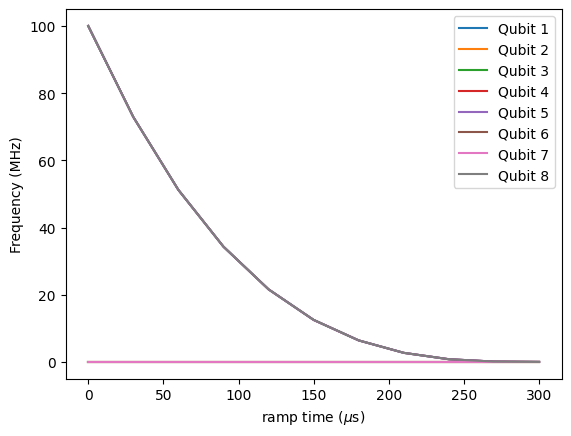

In [16]:
# plot ramps

for i in range(num_qubits):
    plt.plot(ramp_times, [cubic_functions[i](t, None) / (2 * np.pi) for t in ramp_times], label=f'Qubit {i+1}')

plt.xlabel('ramp time ($\mu$s)')
plt.ylabel('Frequency (MHz)')

plt.legend()
plt.show()

In [17]:
basis = list(product(range(num_levels), repeat=num_qubits))

# create mask of tuples that sum to 4
basis_4_indices = np.where([np.sum(basis[i]) == num_particles for i in range(len(basis))])[0]
basis_4 = [basis[i] for i in basis_4_indices]

number_operators_reduced = []

for i in range(num_qubits):
    n = np.zeros((len(basis_4), len(basis_4)))

    for j in range(len(basis_4)):
        state = basis_4[j]

        print(state)
        print(state[i])

        n[j, j] = state[i]

    number_operators_reduced.append(qt.Qobj(n))


(0, 0, 0, 0, 0, 0, 0, 4)
0
(0, 0, 0, 0, 0, 0, 1, 3)
0
(0, 0, 0, 0, 0, 0, 2, 2)
0
(0, 0, 0, 0, 0, 0, 3, 1)
0
(0, 0, 0, 0, 0, 0, 4, 0)
0
(0, 0, 0, 0, 0, 1, 0, 3)
0
(0, 0, 0, 0, 0, 1, 1, 2)
0
(0, 0, 0, 0, 0, 1, 2, 1)
0
(0, 0, 0, 0, 0, 1, 3, 0)
0
(0, 0, 0, 0, 0, 2, 0, 2)
0
(0, 0, 0, 0, 0, 2, 1, 1)
0
(0, 0, 0, 0, 0, 2, 2, 0)
0
(0, 0, 0, 0, 0, 3, 0, 1)
0
(0, 0, 0, 0, 0, 3, 1, 0)
0
(0, 0, 0, 0, 0, 4, 0, 0)
0
(0, 0, 0, 0, 1, 0, 0, 3)
0
(0, 0, 0, 0, 1, 0, 1, 2)
0
(0, 0, 0, 0, 1, 0, 2, 1)
0
(0, 0, 0, 0, 1, 0, 3, 0)
0
(0, 0, 0, 0, 1, 1, 0, 2)
0
(0, 0, 0, 0, 1, 1, 1, 1)
0
(0, 0, 0, 0, 1, 1, 2, 0)
0
(0, 0, 0, 0, 1, 2, 0, 1)
0
(0, 0, 0, 0, 1, 2, 1, 0)
0
(0, 0, 0, 0, 1, 3, 0, 0)
0
(0, 0, 0, 0, 2, 0, 0, 2)
0
(0, 0, 0, 0, 2, 0, 1, 1)
0
(0, 0, 0, 0, 2, 0, 2, 0)
0
(0, 0, 0, 0, 2, 1, 0, 1)
0
(0, 0, 0, 0, 2, 1, 1, 0)
0
(0, 0, 0, 0, 2, 2, 0, 0)
0
(0, 0, 0, 0, 3, 0, 0, 1)
0
(0, 0, 0, 0, 3, 0, 1, 0)
0
(0, 0, 0, 0, 3, 1, 0, 0)
0
(0, 0, 0, 0, 4, 0, 0, 0)
0
(0, 0, 0, 1, 0, 0, 0, 3)
0
(0, 0, 0, 1, 0, 0, 1, 2)
0
(

In [18]:
operator_function_pairs = []

for i in range(num_qubits):
    operator_function_pairs.append([number_operators_reduced[i], cubic_functions[i]])
    

H_tot = [H0] + operator_function_pairs

In [19]:
# set initial state to be four particles on 1,4,5,8

starting_state = (1,0,0,1,1,0,0,1)

starting_state_index = -1

for i in range(len(basis_4)):
    if np.all(np.array(basis_4[i]) == np.array(starting_state)):
        print(basis_4[i])
        starting_state_index = i

starting_state_reduced = np.zeros(len(basis_4))
starting_state_reduced[starting_state_index] = 1

psi0 = qt.Qobj(starting_state_reduced)


(1, 0, 0, 1, 1, 0, 0, 1)


In [20]:
# construct c_ops


c_ops = [np.sqrt(T2)*n for n in number_operators_reduced]
c_ops = [sum([np.sqrt(T2)*n for n in number_operators_reduced])]

In [21]:
result = qt.mesolve(H_tot, psi0, ramp_times, c_ops=c_ops)

MemoryError: Unable to allocate 177. GiB for an array with shape (330, 330, 330, 330) and data type complex128

### 2.4 Monte Carlo trajectories

In [1]:
ntraj = 2

print(len(ramp_times))

result = qt.mcsolve(
    H_tot,
    psi0,
    ramp_times,
    c_ops,
    e_ops=[],
    ntraj=ntraj,
)


NameError: name 'ramp_times' is not defined